In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.datasets import mnist

from keras.layers import Dense, Flatten, Convolution2D, MaxPooling2D, Reshape

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
BACK_C = (.12, .12, .12, 1.)
plt.style.use('dark_background')


In [3]:
params = {'figure.facecolor': BACK_C,
          'axes.facecolor': BACK_C,
          'axes.titleweight': 'bold'}

plt.rcParams.update(params)


# CNN

<br>

>Les couches de convolutions ont pour rôle d'extraire l'information inmportante des images à l'aide de filtres.
>
>Les pooling doit permettre de réduire la quantité de pixels.
>
>C'est la combinaison des couches de convolution et de pooling qui permet d'extraire les features intéressantes, de retirer le bruit tout en réduisant la quantité de paramètres.

In [4]:
def get_cnn(n_class, activation: str = 'relu') -> keras.Sequential:
    model = keras.Sequential([
        # Convolution layers need 3 dimensions for the images.
        # The third dimensions is for the color channels
        Reshape((28, 28, 1)),

        Convolution2D(filters=16, kernel_size=2, activation=activation),
        MaxPooling2D(2),

        Convolution2D(filters=32, kernel_size=2, activation=activation),
        MaxPooling2D(2),

        Flatten(),

        Dense(50, activation=activation),
        Dense(50, activation=activation),

        Dense(n_class, activation='softmax')

    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


def plot_lc(history: dict, metrics: list = ['loss', 'accuracy']) -> None:
    plt.figure(figsize=(20, 8))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.title(f'Learning curve for {metric}\n')
        plt.plot(history[metric], label='train')
        plt.plot(history[f'val_{metric}'], label='val')
        plt.xlabel('epochs')
        plt.ylabel(metric)
        plt.legend()
    plt.show()


def plot_cm(y_true: np.array, y_pred: np.array) -> None:
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(20, 8))
    plt.title('Confusion Matrix\n')
    sns.heatmap(cm, cmap='vlag', annot=True, fmt='d', cbar=False)
    plt.xlabel('y_pred')
    plt.ylabel('y_true')
    plt.show()


In [5]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape


(60000, 28, 28)

> On divise les images par 255 pour obtenir des valeurs comprises entre 0 et 1.
>
>L'intérêt principal est d'éviter de saturer les couches d'activation telles que sig ou tanh.
>
>De manière générale cela permet de converger plus vite vers des poids optimaux.

<br>

```py
def sigmoid(x):
    return 1/(1+np.exp(-x))

print(sigmoid(255))
>>>1.0

print(sigmoid(100))
>>>1.0

print(sigmoid(255/255))
>>>0.7310585786300049

print(sigmoid(100/255))
>>>0.596801812088207

```

In [6]:
# We could do it in the model with and Rescaling layer
X_train = X_train/255
X_test = X_test/255

X_train.dtype

dtype('float64')

In [7]:
cnn = get_cnn(10)
cnn.fit(X_train, y_train, epochs=10, validation_split=.2, batch_size=1024)

Epoch 1/10
47/47 [==============================] - 3s 10ms/step - loss: 1.3573 - accuracy: 0.6158 - val_loss: 0.4674 - val_accuracy: 0.8605
Epoch 2/10
47/47 [==============================] - 0s 6ms/step - loss: 0.3636 - accuracy: 0.8913 - val_loss: 0.2518 - val_accuracy: 0.9272
Epoch 3/10
47/47 [==============================] - 0s 6ms/step - loss: 0.2236 - accuracy: 0.9332 - val_loss: 0.1744 - val_accuracy: 0.9508
Epoch 4/10
47/47 [==============================] - 0s 6ms/step - loss: 0.1616 - accuracy: 0.9509 - val_loss: 0.1451 - val_accuracy: 0.9584
Epoch 5/10
47/47 [==============================] - 0s 6ms/step - loss: 0.1274 - accuracy: 0.9610 - val_loss: 0.1156 - val_accuracy: 0.9660
Epoch 6/10
47/47 [==============================] - 0s 6ms/step - loss: 0.1057 - accuracy: 0.9676 - val_loss: 0.1003 - val_accuracy: 0.9715
Epoch 7/10
47/47 [==============================] - 0s 6ms/step - loss: 0.0904 - accuracy: 0.9722 - val_loss: 0.0906 - val_accuracy: 0.9743
Epoch 8/10
47/47 [=

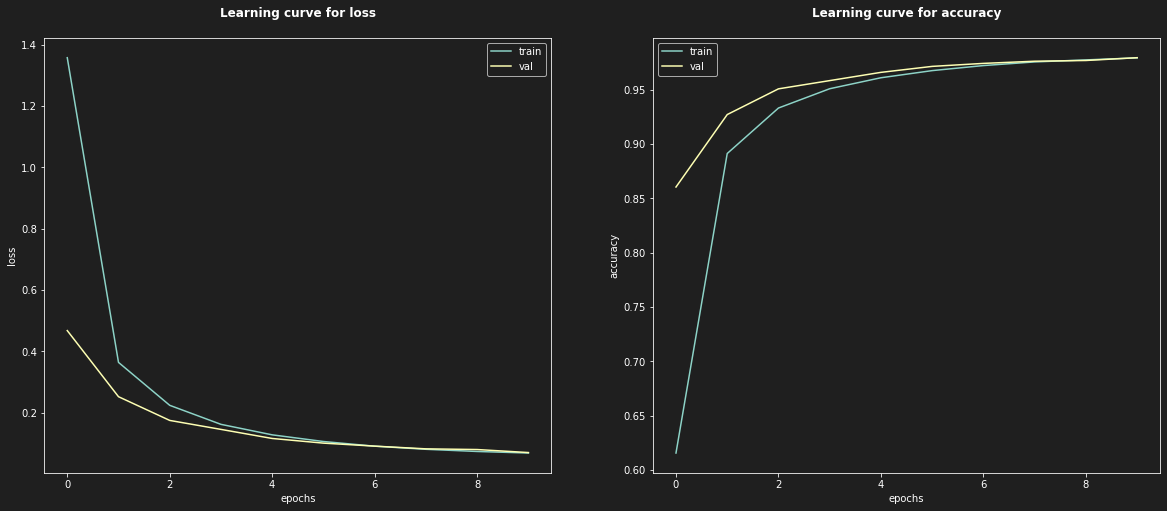

In [8]:
history = cnn.history.history

plot_lc(history)

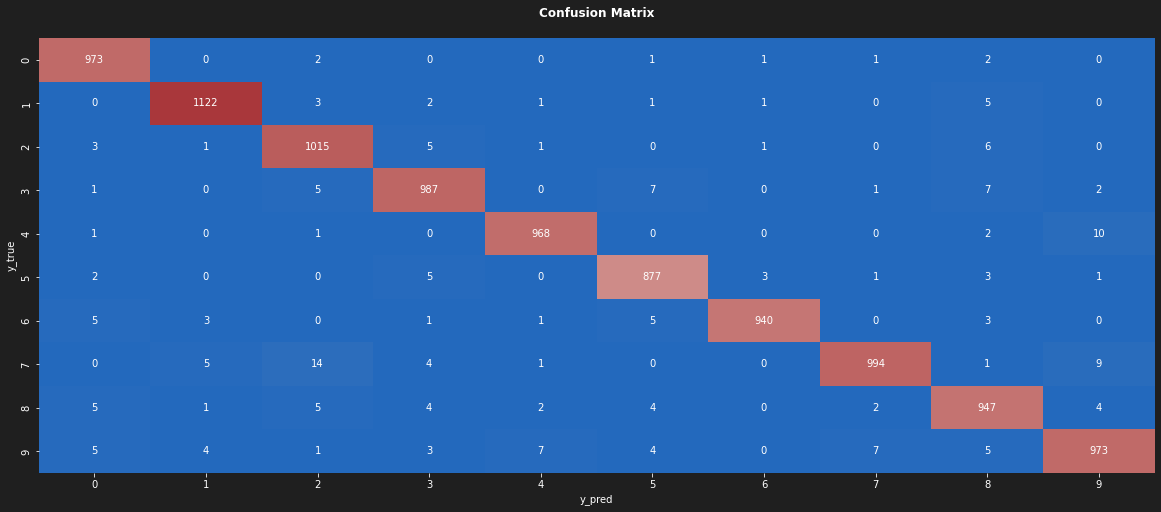

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.99       958
           7       0.99      0.97      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [9]:
y_pred = np.argmax(cnn.predict(X_test), -1)

plot_cm(y_test, y_pred)
print(classification_report(y_test, y_pred))


# Calcul des paramètres

>pour les couches de convolution:
>
>>$$(i*j)*n \space filters*n \space channels+n \space filters$$
>>
>>où i,j = shape du kernel
>>
>>n_filters = nombre de filtres en sortie
>>
>>n_channels = nombre de channels/filtres en entrée
>>
>>n_filtres = correspond aux biais des 16 neuronnes/filtres
>>
>>pour la première convolution:
>>```py
>>(2*2)*16*1+16
>>>>>80
>>```
>>
>>pour la seconde convolution:
>>```py
>>(2*2)*32*16+32
>>>>>2080
>>```
>
>pour les couches denses:
>
>$$n \space features*n \space units+n \space units$$
>
>>Première couche dense:
>>```py
>>1152*50+50
>>>>>57650
>>```
>>
>>Deuxième couche dense:
>>```py
>>50*50+50
>>>>>2550
>>```
>>
>>troisième couche dense:
>>```py
>>50*10+10
>>>>>510
>>```
>>



In [10]:
cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 28, 28, 1)         0         
                                                                 
 conv2d (Conv2D)             (None, 27, 27, 16)        80        
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 12, 12, 32)        2080      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 6, 6, 32)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1152)              0

# Inspectons les convolutions et pooling


Pour pouvoir voir les images après leur passage dans une couche de convolution et de pooling, nous devons modifier la sortie de notre modèle.

Actuellement, la sortie correspond à la dernière couche lorsqu'on procède à un predict.

On peut changer ce comportement pour que lors d'un predict ce ne soit pas les outputs de la dernière couche qui soient renvoyées mais les outputs d'une autre couche.

<br>

In [11]:
# lets print the name and the index for each layer in our cnn
for i, layer in enumerate(cnn.layers):
    print(i, layer.name)

0 reshape
1 conv2d
2 max_pooling2d
3 conv2d_1
4 max_pooling2d_1
5 flatten
6 dense
7 dense_1
8 dense_2


In [12]:
# New model taking the input of our model as the inputs => no change
# Let's set outputs of our new model as the outputs of a pooling layer
filters_gen = keras.Model(inputs=cnn.inputs, outputs=cnn.layers[2].output)

# f_maps = features map (i.e. the features extracted by the conv layer)
f_maps = filters_gen.predict(X_test)
f_maps.shape

(10000, 13, 13, 16)

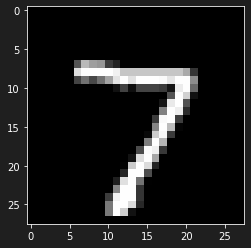

In [13]:
# plot the original img 
plt.imshow(X_test[0], cmap='gray')
plt.show()

## Après la première conv

<br>

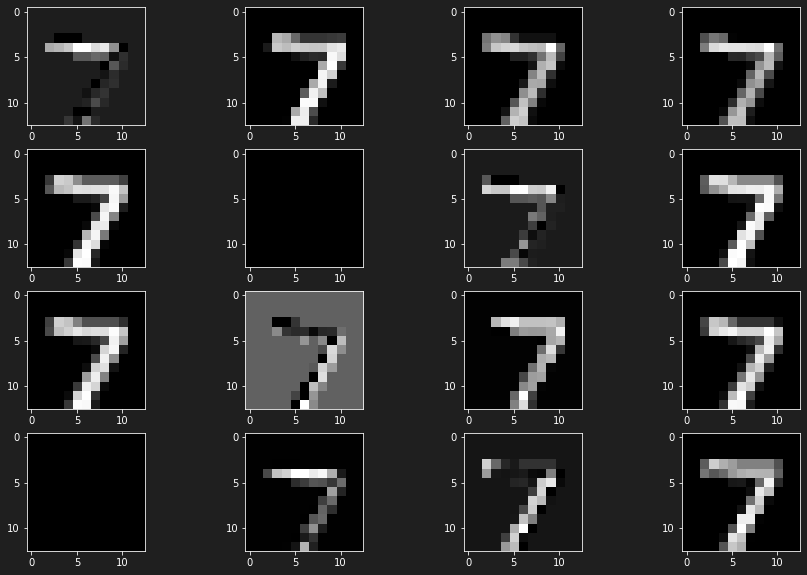

In [14]:
plt.figure(figsize=(15, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    # f_maps[0, :, :, i] means [first img, all pixels, all pixels, i filter]
    plt.imshow(f_maps[0, :, :, i], cmap='gray')
plt.show()

In [15]:
filters_gen = keras.Model(inputs=cnn.inputs, outputs=cnn.layers[4].output)

f_maps = filters_gen.predict(X_test)
f_maps.shape

(10000, 6, 6, 32)

## Après la seconde conv

<br>

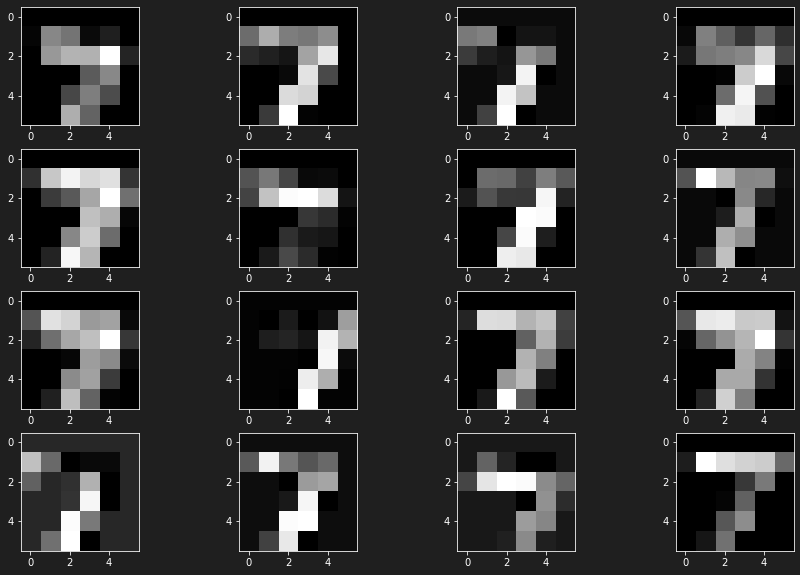

In [16]:
plt.figure(figsize=(15, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(f_maps[0, :, :, i], cmap='gray')
plt.show()